# Week 6 - Task 2: Transfer Learning with VGG16 (Fine-tuning)

## Setup: Mount Drive & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
DATASET_ROOT = '/content/drive/MyDrive/AI ML/Week5/FruitinAmazon/FruitinAmazon'

train_dir = os.path.join(DATASET_ROOT, 'train')
test_dir  = os.path.join(DATASET_ROOT, 'test')

assert os.path.isdir(train_dir), f"train_dir not found: {train_dir}"
assert os.path.isdir(test_dir),  f"test_dir not found: {test_dir}"

---
## Step 1: Load & Preprocess Datasets


In [5]:
# Hyperparameters
IMG_HEIGHT       = 224
IMG_WIDTH        = 224
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2
SEED             = 42

print(f"Image size : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size : {BATCH_SIZE}")

Image size : 224x224
Batch size : 32


In [6]:
# Load train and validation datasets
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="both",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

# Load test dataset (no split, no shuffle)
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES  = len(class_names)
print(f"\nClass names ({NUM_CLASSES}):", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

Class names (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
# Apply VGG16-specific preprocessing (zero-centre w.r.t. ImageNet)

from tensorflow.keras.applications.vgg16 import preprocess_input

def vgg_preprocess(images, labels):
    return preprocess_input(images), labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(vgg_preprocess).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.map(vgg_preprocess).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(vgg_preprocess).cache().prefetch(AUTOTUNE)

print("Datasets preprocessed for VGG16 input.")

Datasets preprocessed for VGG16 input.


---
## Step 2: Load Pre-trained VGG16 (without top classification layers)

In [8]:
# Load VGG16 base model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print(f"Base model loaded: {base_model.name}")
print(f"Total layers in base: {len(base_model.layers)}")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base model loaded: vgg16
Total layers in base: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

---
## Step 3: Freeze the Base Model Layers


In [9]:
# Freeze all layers in the base model
base_model.trainable = False

# Verify
trainable_count    = sum(1 for l in base_model.layers if l.trainable)
non_trainable_count = sum(1 for l in base_model.layers if not l.trainable)

print(f"Froze {non_trainable_count} layers  |  {trainable_count} layers remain trainable")

Froze 19 layers  |  0 layers remain trainable


---
## Step 4: Add Custom Classification Head


In [10]:
# Build custom classification head on top of VGG16
x = base_model.output
x = GlobalAveragePooling2D()(x)          # (None, 512)
x = Dense(1024, activation='relu')(x)    # (None, 1024)
x = Dropout(0.5)(x)
x = Dense(512,  activation='relu')(x)    # (None, 512)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)  # (None, 6)

print("Custom head added on top of VGG16.")

Custom head added on top of VGG16.


---
## Step 5: Create the Final Model

In [11]:
# Combine base model + custom head
model = Model(inputs=base_model.input, outputs=output, name='VGG16_transfer')

# Count trainable vs frozen parameters
total_params     = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
frozen_params    = total_params - trainable_params

print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Frozen params    : {frozen_params:,}")

model.summary()

Total params     : 15,767,878
Trainable params : 1,053,190
Frozen params    : 14,714,688


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,767,878 (60.15 MB)

 Trainable params: 1,053,190 (4.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

---
## Step 6: Compile & Train

In [12]:
# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # Lower LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath='best_model_w6_task2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 30   # Fewer epochs needed — pre-trained features converge faster

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb],
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.0574 - loss: 8.3206  
Epoch 1: val_accuracy improved from None to 0.22222, saving model to best_model_w6_task2.keras

Epoch 1: finished saving model to best_model_w6_task2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 70s 15s/step - accuracy: 0.0972 - loss: 8.5819 - val_accuracy: 0.2222 - val_loss: 2.7929
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.1669 - loss: 6.8899
Epoch 2: val_accuracy improved from 0.22222 to 0.44444, saving model to best_model_w6_task2.keras

Epoch 2: finished saving model to best_model_w6_task2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step - accuracy: 0.1944 - loss: 6.2417 - val_accuracy: 0.4444 - val_loss: 1.5695
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2231 - loss: 6.7112
Epoch 3: val_accuracy improved from 0.44444 to 0.61111, saving model to best_model_w6_task2.keras

Epoch 3: finished saving model to best_model_w6_task2.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accu

---
## Step 7: Plot Training History

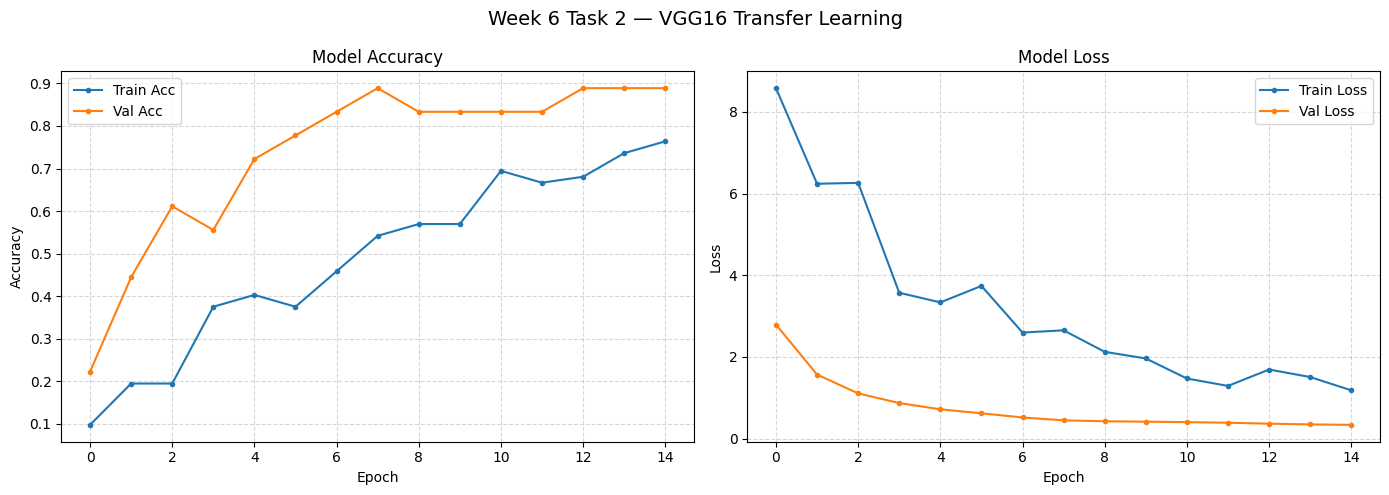

In [13]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'],     label='Train Acc',  marker='o', markersize=3)
    axes[0].plot(history.history['val_accuracy'], label='Val Acc',    marker='o', markersize=3)
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(history.history['loss'],     label='Train Loss', marker='o', markersize=3)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   marker='o', markersize=3)
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history, title='Week 6 Task 2 — VGG16 Transfer Learning')

---
## Step 8: Evaluate on Test Set

In [14]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step - accuracy: 0.6333 - loss: 1.1926

Test Loss     : 1.1926
Test Accuracy : 0.6333 (63.33%)


---
## Step 9: Classification Report

In [15]:
# Collect predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report — VGG16 Transfer Learning:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report — VGG16 Transfer Learning:
              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
     cupuacu       0.75      0.60      0.67         5
    graviola       1.00      0.80      0.89         5
     guarana       0.62      1.00      0.77         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.33      0.40      0.36         5

    accuracy                           0.63        30
   macro avg       0.66      0.63      0.63        30
weighted avg       0.66      0.63      0.63        30



---
## Step 10: Inference Visualisation

Found 30 files belonging to 6 classes.


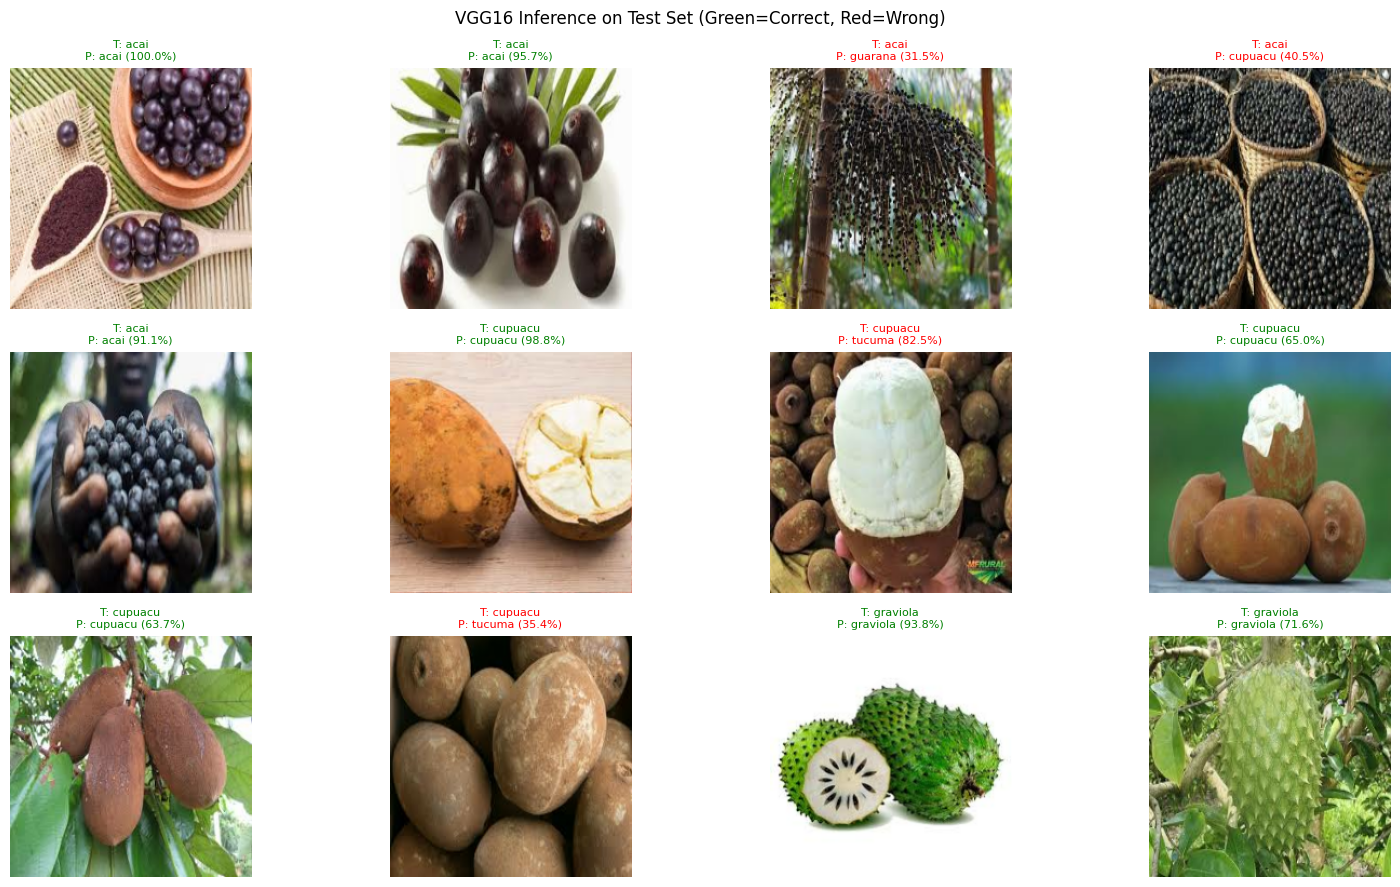

In [16]:
# Load a fresh (unpreprocessed) test batch for display
raw_test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=12,
    shuffle=False,
)

from tensorflow.keras.applications.vgg16 import preprocess_input

plt.figure(figsize=(16, 9))
for raw_images, raw_labels in raw_test_ds.take(1):
    preprocessed = preprocess_input(tf.cast(raw_images, tf.float32))
    preds = model.predict(preprocessed, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(min(12, len(raw_images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(raw_images[i].numpy().astype('uint8'))
        true_cls = class_names[raw_labels[i].numpy()]
        pred_cls = class_names[pred_labels[i]]
        conf     = preds[i][pred_labels[i]] * 100
        colour   = 'green' if true_cls == pred_cls else 'red'
        ax.set_title(f"T: {true_cls}\nP: {pred_cls} ({conf:.1f}%)",
                     color=colour, fontsize=8)
        ax.axis('off')

plt.suptitle('VGG16 Inference on Test Set (Green=Correct, Red=Wrong)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 11: Compare — Transfer Learning vs Training from Scratch


In [17]:
# ── Manual: fill in your results after running both notebooks ──────────────────
results = {
    'Week 5 (Basic CNN)':            {'test_acc': None, 'params': None},  # fill
    'Week 6 Task 1 (BN+Dropout)':    {'test_acc': None, 'params': None},  # fill
    'Week 6 Task 2 (VGG16 TL)':      {'test_acc': test_acc, 'params': trainable_params},
}

print(f"{'Model':<30}{'Test Acc':>12}{'Trainable Params':>20}")
print('=' * 65)
for model_name, r in results.items():
    acc = f"{r['test_acc']*100:.2f}%" if r['test_acc'] is not None else 'N/A'
    prm = f"{r['params']:,}" if r['params'] is not None else 'N/A'
    print(f"{model_name:<30}{acc:>12}{prm:>20}")

Model                             Test Acc    Trainable Params
Week 5 (Basic CNN)                     N/A                 N/A
Week 6 Task 1 (BN+Dropout)             N/A                 N/A
Week 6 Task 2 (VGG16 TL)            63.33%           1,053,190


---
## (Optional) Step 12: Fine-Tuning — Unfreeze Top VGG16 Layers

For even better accuracy you can **unfreeze** the last few VGG16 convolutional blocks
and let them also update during a second round of training at a very low learning rate.

Trainable params after unfreeze: 8,132,614
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5608 - loss: 2.2366   
Epoch 1: val_accuracy improved from None to 0.77778, saving model to best_model_w6_task2_finetuned.keras

Epoch 1: finished saving model to best_model_w6_task2_finetuned.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5417 - loss: 2.2225 - val_accuracy: 0.7778 - val_loss: 0.4191
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5963 - loss: 1.8294
Epoch 2: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.5139 - loss: 2.3611 - val_accuracy: 0.7778 - val_loss: 0.3957
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5307 - loss: 2.4860
Epoch 3: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.5139 - loss: 2.4039 - val_accuracy: 0.7778 - val_loss: 0.3929
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.6644 - loss: 1.3916


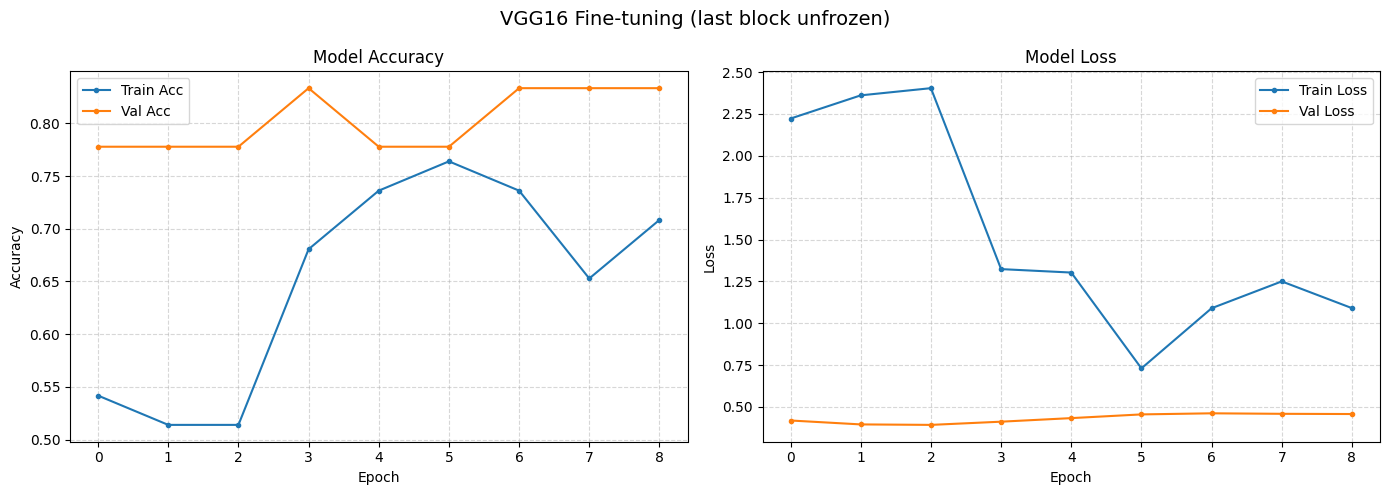

In [18]:
# Unfreeze the last convolutional block of VGG16 (block5)
base_model.trainable = True

# Keep all layers frozen except the last block (layers[-4:] ≈ block5_conv1,2,3 + pool)
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with a much lower LR to avoid destroying pre-trained weights
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_after = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"Trainable params after unfreeze: {trainable_after:,}")

# Short fine-tuning run
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[ModelCheckpoint('best_model_w6_task2_finetuned.keras',
                               monitor='val_accuracy', save_best_only=True, verbose=1),
               EarlyStopping(monitor='val_accuracy', patience=5,
                             restore_best_weights=True, verbose=1)],
)

# Evaluate fine-tuned model
ft_loss, ft_acc = model.evaluate(test_ds, verbose=1)
print(f"\nFine-tuned Test Accuracy: {ft_acc*100:.2f}%")
plot_history(history_ft, title='VGG16 Fine-tuning (last block unfrozen)')